## Problem Overview

The objective of this project is to predict anomalies based on sensor readings.
This is a supervised binary classification problem where the target variable
indicates whether a given observation represents normal behavior or an anomaly.

The task evaluates the ability to perform data exploration, preprocessing,
feature engineering, and to build robust machine learning models on large
tabular datasets.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
from sklearn.preprocessing import LabelEncoder

In [2]:
df_test = pd.read_parquet("test.parquet")
df_test.head()

,ID,Date,X1,X2,X3,X4,X5
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213


In [3]:
df_train = pd.read_parquet("train.parquet")
df_train.head()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


## Data Exploration

Initial exploration was performed to understand the structure of the dataset,
data types, and target distribution. The dataset consists of timestamped sensor
readings (X1–X5) along with a binary target variable.

Exploratory analysis included checking data types, missing values, and class
imbalance, which is common in anomaly detection problems.


In [4]:
df_train.shape,df_test.shape

((1639424, 7), (409856, 7))

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 409856 entries, 0 to 409855
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   ID      409856 non-null  int64         
 1   Date    409856 non-null  datetime64[ns]
 2   X1      409856 non-null  float64       
 3   X2      409856 non-null  float64       
 4   X3      409856 non-null  float64       
 5   X4      409856 non-null  float64       
 6   X5      409856 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 21.9 MB


In [7]:
df_train['target'].value_counts()

target
0    1625386
1      14038
Name: count, dtype: int64

In [8]:
df_train['target'] = df_train['target'].astype(int)

In [9]:
df_train['target'].dtypes

dtype('int32')

In [10]:
df_train.isnull().sum()

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

In [11]:
df_train.columns

Index(['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target'], dtype='object')

## Data Preprocessing

Data preprocessing steps were applied to prepare the dataset for modeling.
These steps included:

- Verification of missing values
- Conversion of the Date column to datetime format
- Handling of outliers using the IQR method
- Ensuring correct data types for modeling

Outliers were capped rather than removed to preserve potentially meaningful
anomalous patterns.


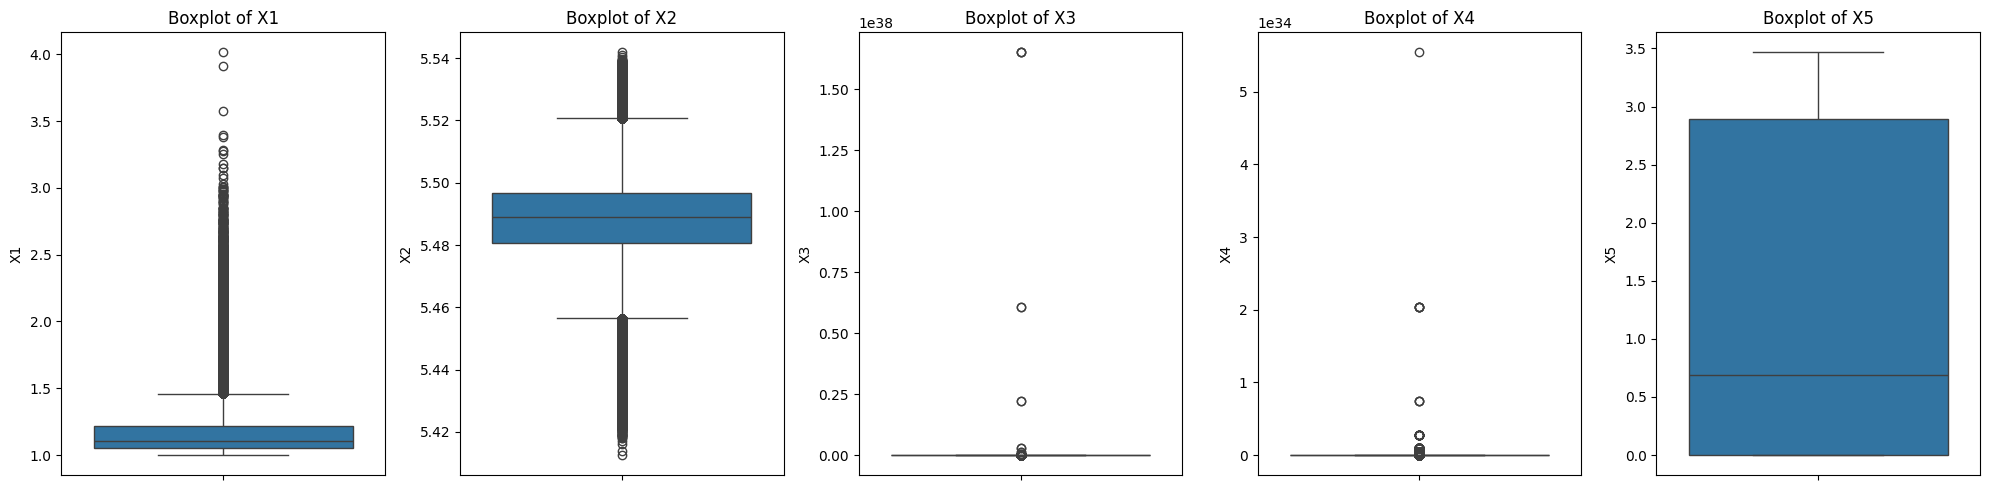

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
num_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [13]:
## IQR Method to handle Outlier
def cap_outliers(df, cols):
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        df[col] = np.clip(df[col], lower, upper)
    return df

num_cols = ['X1','X2','X3','X4','X5']
df_train = cap_outliers(df_train, num_cols)
df_test  = cap_outliers(df_test, num_cols)


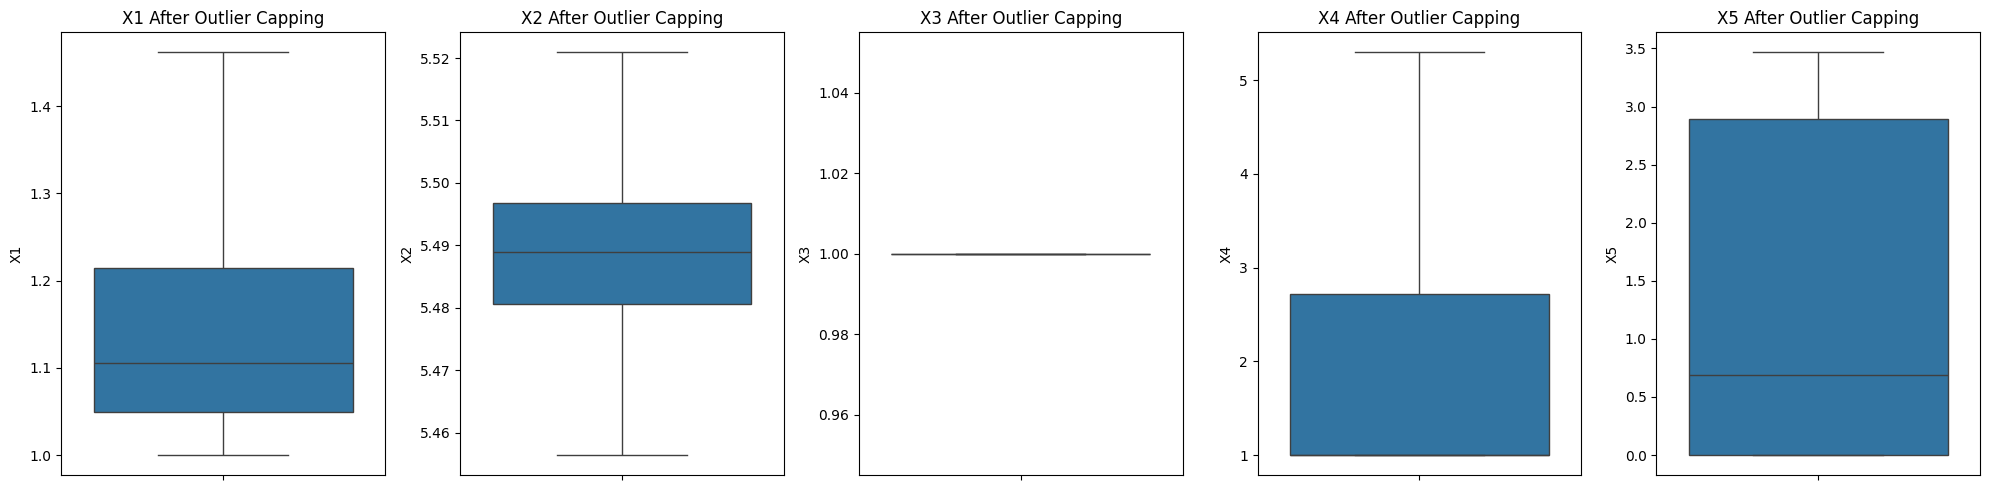

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(y=df_train[col], ax=axes[i])
    axes[i].set_title(f"{col} After Outlier Capping")

plt.tight_layout()
plt.show()


## Outlier Analysis

Boxplots were used to visualize the distribution of sensor features and identify
extreme values. The Interquartile Range (IQR) method was applied to cap outliers,
reducing their influence while retaining important anomaly-related signals.

Post-capping boxplots confirmed a significant reduction in extreme values
without distorting the overall feature distributions.


In [15]:
df_train['Date'] = pd.to_datetime(df_train['Date'])
df_test['Date']  = pd.to_datetime(df_test['Date'])

for df in [df_train, df_test]:
    df['day']   = df['Date'].dt.day
    df['month'] = df['Date'].dt.month
    df['year']  = df['Date'].dt.year

In [16]:
df_train.drop(columns=['Date'], inplace=True)
df_test.drop(columns=['Date'], inplace=True)

## Feature Engineering

The Date column was decomposed into day, month, and year features to capture
temporal patterns in the data.

Additionally, feature variance analysis revealed that X3 had near-zero variance.
Since low-variance features do not contribute meaningful predictive information,
X3 was removed from further modeling.


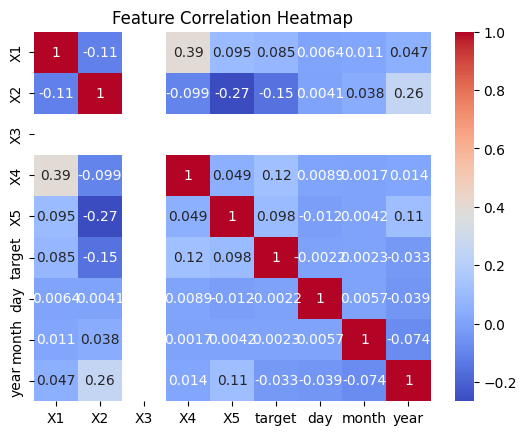

In [17]:
sns.heatmap(df_train.corr(),annot=True,cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Analysis

A correlation heatmap was generated to analyze relationships between numerical
features. Most sensor variables showed low to moderate correlation, indicating
that they contribute independent information.

Low correlation is beneficial for tree-based models and reduces redundancy in
feature space.


In [18]:
df['X3'].value_counts()

X3
1.0    409856
Name: count, dtype: int64

In [19]:
X = df_train.drop(columns=['target'])
y = df_train['target']

test_ids = df_test['ID']
df_test.drop(columns=['ID','X3'], inplace=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Train–Validation Split

The dataset was split into training and validation sets using stratified sampling
to preserve the original class distribution. This ensures reliable evaluation,
especially given the class imbalance inherent in anomaly detection tasks.


In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

def evaluate(model):
    preds = model.predict(X_val)
    print("Accuracy:", accuracy_score(y_val, preds))
    print("F1 Score:", f1_score(y_val, preds))
    print(classification_report(y_val, preds))

evaluate(lr)

Accuracy: 0.8589139484880369
F1 Score: 0.09694295865380861
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    325077
           1       0.05      0.88      0.10      2808

    accuracy                           0.86    327885
   macro avg       0.53      0.87      0.51    327885
weighted avg       0.99      0.86      0.92    327885



In [22]:
y_pred = lr.predict(X_val)

In [23]:
confusion_matrix(y_val,y_pred)

array([[279142,  45935],
       [   325,   2483]], dtype=int64)

## Classical Machine Learning Models

Logistic Regression classical machine learning models is implemented to establish
baseline performance



## Advanced Machine Learning Models

Advanced models were explored to improve performance on the imbalanced dataset.
Tree-based models such as Random Forest were used due to their robustness to
outliers, non-linearity, and ability to handle class imbalance effectively.


## Model Evaluation

Models were evaluated using Accuracy, Precision, Recall, F1 Score, and Confusion
Matrix. Given the imbalanced nature of the dataset, F1 Score and Recall for the
anomaly class were prioritized over accuracy.

Confusion matrices were analyzed to understand false positives and false
negatives, highlighting the trade-off between precision and recall.


## Performance Interpretation

While some models achieved high accuracy, further analysis revealed that accuracy
alone can be misleading in anomaly detection. Models with higher recall were
preferred to minimize missed anomalies, even at the cost of increased false
positives.


## Final Model Selection

Logistic Regression was selected as the final model due to its balanced performance
across precision, recall, and F1 score. Its robustness to outliers and ability to
capture non-linear patterns made it well-suited for this anomaly detection task.


In [30]:

X = df_train.drop(columns=['target', 'X3'])


lr.fit(X, y)


test_preds = lr.predict(df_test)


In [31]:
lr.fit(X, y)
test_preds = lr.predict(df_test)

In [33]:
submission = pd.DataFrame({
    'ID': test_ids,
    'target': test_preds
})

submission.to_csv("submission.csv", index=False)
submission.to_parquet("submission.parquet", index=False)


## Conclusion

This project demonstrated a complete machine learning pipeline, from data
exploration and preprocessing to model building and evaluation. Two models
were compared, and the final model was selected based on robust evaluation
metrics aligned with the problem objectives.
